# Pulsos con simulación

In [1]:
# from oficial python
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch
from matplotlib import cm
import matplotlib as mpl
from qutip import basis, tensor
import time
from sklearn.model_selection import train_test_split
import pennylane as qml
import os
import pandas as pd

# own modules:
from dll.spin_procesor_modificated import Quantum_Spin_Proces
from dll.main_fun import make_IRIS_v2, pulse_x_with_noise, pulse_x, pulse_z
from dll. baseline_dru_v2 import Modelo_DRU
from dll.models import qcircuit_1_qubit_mixed, qcircuit_2_qubit_mixed, qcircuit_4_qubit_mixed
from dll.cost_functions import fidelity_cost
from dll.gate_procesor_modificated import CompositeGateProcessor

In [2]:
def calculate_fidelity(state_base_line, state_spins):
  # convert spin to dm
  nf, nc = state_spins.shape
  if nc == 1:
    dm_spin = state_spins @ state_spins.conj().T
  # calculare fidelity:
  F  = qml.math.fidelity(state_base_line, dm_spin)
  return F
  

In [4]:
def make_total_pulse(B0_pulses):
  # Convertir el array a tipo float para poder asignar NaN
  B0_pulses = B0_pulses.astype(float)

  # Crear un vector complementario donde los ceros se reemplazan por unos
  B0_complement = np.where(B0_pulses == 0, np.min(B0_pulses), B0_pulses)

  # Crear una máscara para los valores que son cero en el vector original
  mask = B0_pulses == 0

  # Crear una copia del vector original para graficar los valores reales mayores que cero
  B0_pulses_real = np.copy(B0_pulses)
  B0_pulses_real[mask] = np.nan  # Reemplazar los ceros con NaN para no plotearlos

  # Crear una copia del vector complementario para graficar los valores complementados
  B0_pulses_complement = np.copy(B0_complement)
  B0_pulses_complement[~mask] = np.nan  # Reemplazar los valores no complementados con NaN
  
  return B0_complement, B0_pulses_complement

In [ ]:
def plot_pulses_v33(self, verbose=1, key_show='all', entangl=False, 
                   fontsize_axes=12, fontsize_title=14, fontsize_text=11):
    # Tomar todos los pulsos:
    resultado = self.pulse_type
    # Definir el tiempo global de simulación:
    glob_time = self.global_time
    
    # Por cada pulso...
    for key in resultado:
        # Identificar su tipo:
        list_pulses = resultado[key]
        
        # Caso pulso unitario:
        if list_pulses[0]['Type_pulse'] == 'Unitary':
            print(key)
            global_time_sim = np.linspace(0, glob_time, 1000)  # Tiempo total de simulación
            B1_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso Bx
            B0_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso B0
            
            for dict_pulse in list_pulses:
                # B0 results
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                B0_i = dict_pulse['B0'] * pulse_z(global_time_sim, args2)
                # Se guarda reiterativamente los pulsos cuadrados:
                B0_pulses += np.array(B0_i)
                
                # B1 results
                if self.tf_noise == True:
                    dv = self.noise_std/abs(dict_pulse['B1']) if dict_pulse['B1'] != 0 else 0
                else:
                    dv = 0
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f'], "std_noise": dv}
                B1_i = dict_pulse['B1'] * pulse_x_with_noise(global_time_sim, args2)
                B1_pulses += np.array(B1_i)
            
            # Plot para B0
            #B0_pulses_blue, B0_pulses_red = make_total_pulse(np.abs(B0_pulses))
            B0_pulses_blue, B0_pulses_red = make_total_pulse(B0_pulses)
            B0_pulses_blue[0] = B0_pulses_blue[-1] = 0
            B0_pulses_red[0] = B0_pulses_red[-1] = 0
            
            plt.figure(figsize=(8, 3))
            # plt.plot(global_time_sim * 1e9, np.abs(B0_pulses), linewidth=0.5, color='darkblue')
            plt.plot(global_time_sim * 1e9, B0_pulses, linewidth=0.5, color='darkblue')  
            plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')
            plt.plot(global_time_sim * 1e9, B0_pulses_red, 'r-', label=r'Virtual $I$ gate')
            plt.title("Pulse sequence for Bz", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bz [T]", fontsize=fontsize_axes)
            plt.grid()
            if self.N_qubits > 1:
                plt.legend()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B0_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

            # Plot para B1
            plt.figure(figsize=(8, 3))
            plt.plot(global_time_sim * 1e9, B1_pulses, linewidth=1.7, color='darkblue')
            plt.title("Pulse sequence for Bx", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bx [T]", fontsize=fontsize_axes)
            plt.grid()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B1_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

        elif list_pulses[0]['Type_pulse'] == "Two_Qubits":
            global_time_sim = np.linspace(0, glob_time, 100000)
            fig, ax = plt.subplots(figsize=(8, 3))
            
            swap_color = 'darkblue'
            sqrt_swap_color = 'darkgreen'
            swap_plotted = False
            sqrt_swap_plotted = False
            
            for th, dict_pulse in enumerate(list_pulses):
                J_pulses = np.zeros(len(global_time_sim))
                t_i = dict_pulse['t_i']  # Tiempo inicial
                t_f = dict_pulse['t_f']  # Tiempo final
                J = dict_pulse['J']  # Amplitud de J
                duration = t_f - t_i  # Duración del pulso
                Swap_time = np.pi / J  # Tiempo esperado para SWAP
                sqrt_Swap_time = np.pi / (2 * J)  # Tiempo esperado para sqrt SWAP
                
                label = "SWAP" if abs(duration - Swap_time) < 1e-13 else r"$\sqrt{SWAP}$" if abs(duration - sqrt_Swap_time) < 1e-13 else "Unknown"
                color = swap_color if label == "SWAP" else sqrt_swap_color if label == r"$\sqrt{SWAP}$" else 'gray'
                
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                hbar = 6.582e-13
                J_i = hbar * dict_pulse['J'] * pulse_x(global_time_sim, args2)
                J_pulses += np.array(J_i)
                
                t_center = (t_f + t_i) / 2
                y_text = hbar * dict_pulse['J'] * 1.05
                ax.text((t_center * 1e9) * np.random.uniform(0.99, 1.00), y_text,
                        label, horizontalalignment='center',
                        verticalalignment='bottom', rotation=90, fontsize=fontsize_text)
                
                if label == "SWAP" and not swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label='SWAP')
                    swap_plotted = True
                elif label == r"$\sqrt{SWAP}$" and not sqrt_swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label=r'$\sqrt{SWAP}$')
                    sqrt_swap_plotted = True
                else:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color)
            
            ax.set_xlabel("time [ns]", fontsize=fontsize_axes)
            ax.set_ylabel("J [meV]", fontsize=fontsize_axes)
            ax.set_ylim([0, (np.max(J_pulses)) * 1.30])
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            plt.grid()
            ax.legend()
            
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"J_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re  # Necesario para extraer índices de los keys (ej: "q_0" -> 0)

def plot_pulses_v33_2(self, verbose=1, key_show='all', entangl=False, 
                   fontsize_axes=12, fontsize_title=14, fontsize_text=11):
    """
    Grafica la secuencia de pulsos y retorna las estructuras de datos
    compatibles con la simulación por trotterización.
    """
    # Tomar todos los pulsos:
    resultado = self.pulse_type
    # Definir el tiempo global de simulación:
    glob_time = self.global_time
    
    # --- Estructuras para el return compatible con la simulación ---
    # Inicializamos lista de listas para B (un sub-lista por qubit)
    # Asumimos que self.N_qubits está definido correctamente.
    B_pulse_intervals_per_site = [[] for _ in range(self.N_qubits)]
    
    # Inicializamos diccionario para J (clave: tupla (i,j), valor: lista de intervalos)
    # Usamos diccionario porque J depende del par específico.
    J_pulse_intervals_dict = {} 
    # ---------------------------------------------------------------

    # Por cada pulso...
    for key in resultado:
        # Identificar su tipo:
        list_pulses = resultado[key]
        
        # Extraer índices numéricos del key (ej: "q_1" -> [1], "q0_q1" -> [0, 1])
        indices = [int(s) for s in re.findall(r'\d+', str(key))]
        
        # Caso pulso unitario (Single Qubit):
        if list_pulses[0]['Type_pulse'] == 'Unitary':
            if verbose > 0: print(f"Processing Unitary key: {key}")
            
            # Asumimos que si es unitario, hay un solo índice en el key
            qubit_idx = indices[0] if indices else 0
            
            global_time_sim = np.linspace(0, glob_time, 1000)  # Tiempo total de simulación
            B1_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso Bx
            B0_pulses = np.zeros(len(global_time_sim))  # Vector para guardar pulso B0
            
            for dict_pulse in list_pulses:
                # --- Recolección de datos para Simulación (B fields) ---
                t_i, t_f = dict_pulse['t_i'], dict_pulse['t_f']
                # B1 es campo en X, B0 es campo en Z (incluye Virtual I/Z)
                bx_amp = dict_pulse.get('B1', 0.0)
                bz_amp = dict_pulse.get('B0', 0.0)
                
                # Solo agregamos si el intervalo es válido y hay amplitud
                if t_f > t_i:
                    # Formato: (t_start, t_end, (Bx, By, Bz))
                    # Nota: Las I_VIRTUALS suelen ser rotaciones Z, aquí incluidas en B0 (Bz)
                    B_pulse_intervals_per_site[qubit_idx].append(
                        (t_i, t_f, (bx_amp, 0.0, bz_amp))
                    )
                # ------------------------------------------------------

                # B0 results (Plotting logic)
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                # Nota: pulse_z debe estar definido en el contexto global o self
                B0_i = dict_pulse['B0'] * pulse_z(global_time_sim, args2)
                B0_pulses += np.array(B0_i)
                
                # B1 results (Plotting logic)
                if self.tf_noise == True:
                    dv = self.noise_std/abs(dict_pulse['B1']) if dict_pulse['B1'] != 0 else 0
                else:
                    dv = 0
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f'], "std_noise": dv}
                # Nota: pulse_x_with_noise debe estar definido
                B1_i = dict_pulse['B1'] * pulse_x_with_noise(global_time_sim, args2)
                B1_pulses += np.array(B1_i)
            
            # Plot para B0
            # make_total_pulse debe estar definido
            B0_pulses_blue, B0_pulses_red = make_total_pulse(B0_pulses)
            B0_pulses_blue[0] = B0_pulses_blue[-1] = 0
            B0_pulses_red[0] = B0_pulses_red[-1] = 0
            
            plt.figure(figsize=(8, 3))
            plt.plot(global_time_sim * 1e9, B0_pulses, linewidth=0.5, color='darkblue')  
            plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')
            plt.plot(global_time_sim * 1e9, B0_pulses_red, 'r-', label=r'Virtual $I$ gate')
            plt.title(f"Pulse sequence for Bz (Qubit {qubit_idx})", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bz [T]", fontsize=fontsize_axes)
            plt.grid()
            if self.N_qubits > 1:
                plt.legend()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B0_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            # Crear directorio si no existe para evitar error
            os.makedirs(os.path.dirname(path_to_save_img), exist_ok=True)
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

            # Plot para B1
            plt.figure(figsize=(8, 3))
            plt.plot(global_time_sim * 1e9, B1_pulses, linewidth=1.7, color='darkblue')
            plt.title(f"Pulse sequence for Bx (Qubit {qubit_idx})", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bx [T]", fontsize=fontsize_axes)
            plt.grid()
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"B1_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

        elif list_pulses[0]['Type_pulse'] == "Two_Qubits":
            # Identificar par de qubits
            if len(indices) >= 2:
                pair_key = tuple(sorted(indices[:2])) # (min, max) para consistencia
            else:
                pair_key = (0, 1) # Default fallback

            global_time_sim = np.linspace(0, glob_time, 100000)
            fig, ax = plt.subplots(figsize=(8, 3))
            
            swap_color = 'darkblue'
            sqrt_swap_color = 'darkgreen'
            swap_plotted = False
            sqrt_swap_plotted = False
            
            # Inicializar lista para este par en el diccionario de retorno
            if pair_key not in J_pulse_intervals_dict:
                J_pulse_intervals_dict[pair_key] = []

            for th, dict_pulse in enumerate(list_pulses):
                J_pulses = np.zeros(len(global_time_sim))
                t_i = dict_pulse['t_i']  # Tiempo inicial
                t_f = dict_pulse['t_f']  # Tiempo final
                J = dict_pulse['J']  # Amplitud de J
                
                # --- Recolección de datos para Simulación (J coupling) ---
                if t_f > t_i:
                    # Formato: (t_start, t_end, amplitude)
                    J_pulse_intervals_dict[pair_key].append((t_i, t_f, J))
                # ---------------------------------------------------------

                duration = t_f - t_i  # Duración del pulso
                Swap_time = np.pi / J if J != 0 else np.inf
                sqrt_Swap_time = np.pi / (2 * J) if J != 0 else np.inf
                
                label = "SWAP" if abs(duration - Swap_time) < 1e-13 else r"$\sqrt{SWAP}$" if abs(duration - sqrt_Swap_time) < 1e-13 else "Unknown"
                color = swap_color if label == "SWAP" else sqrt_swap_color if label == r"$\sqrt{SWAP}$" else 'gray'
                
                args2 = {"t_init": dict_pulse['t_i'], "t_final": dict_pulse['t_f']}
                hbar = 6.582e-13
                # Nota: pulse_x debe estar definido
                J_i = hbar * dict_pulse['J'] * pulse_x(global_time_sim, args2)
                J_pulses += np.array(J_i)
                
                t_center = (t_f + t_i) / 2
                y_text = hbar * dict_pulse['J'] * 1.05
                ax.text((t_center * 1e9) * np.random.uniform(0.99, 1.00), y_text,
                        label, horizontalalignment='center',
                        verticalalignment='bottom', rotation=90, fontsize=fontsize_text)
                
                if label == "SWAP" and not swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label='SWAP')
                    swap_plotted = True
                elif label == r"$\sqrt{SWAP}$" and not sqrt_swap_plotted:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color, label=r'$\sqrt{SWAP}$')
                    sqrt_swap_plotted = True
                else:
                    ax.plot(global_time_sim * 1e9, J_pulses, linewidth=1.7, color=color)
            
            ax.set_xlabel("time [ns]", fontsize=fontsize_axes)
            ax.set_ylabel("J [meV]", fontsize=fontsize_axes)
            # Evitar error si J_pulses está vacío o es todo ceros
            max_J = np.max(J_pulses) if len(J_pulses) > 0 else 1.0
            ax.set_ylim([0, max_J * 1.30])
            plt.rcParams['text.usetex'] = True
            plt.rcParams['font.family'] = 'Times New Roman'
            plt.grid()
            ax.legend()
            
            path_to_save_img = os.path.join("results_of_test", "test_3",
                                            f"J_PSeq_{self.N_qubits}_entgl_{entangl}_q_obj_{key}.pdf")
            os.makedirs(os.path.dirname(path_to_save_img), exist_ok=True)
            plt.savefig(path_to_save_img, format='pdf', bbox_inches='tight')
            plt.show()

    # Retornar los intervalos listos para la función de simulación
    # B_pulse_intervals_per_site: Lista de listas (índice = qubit)
    # J_pulse_intervals_dict: Diccionario {(q_i, q_j): [(t0, t1, amp), ...]}
    return B_pulse_intervals_per_site, J_pulse_intervals_dict


In [ ]:
# Pulsos para 1qubit:
X, y =  make_IRIS_v2(3,3)

model = Modelo_DRU(qcircuit_1_qubit_mixed, fidelity_cost,
                        epochs = 5, n_clases = 3, n_qubits = 1,
                        features = 3, num_layers = 10, alpha_noise = 0.0, val_prc = 0.2,
                        save_process = False, save_w_states = False)

# splita data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# get optimized parameters
paramters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=100,
                                     N_qubits = 1,
                                     tf_noise = False,
                                     noise_std = 0.0000, save_pulses= True,
                                     J = 1.52e11 )

state_dru = dru_circuit.qcircuit_DRU_1_Qubit(paramters_1q,
                                             model.X_val[1],
                                             bias=bias_1q)

# plot
plot_pulses_v33_2(dru_circuit, fontsize_axes=17, fontsize_title=24, fontsize_text=9)

Epoch: 100%|██████████| 5/5 [00:22<00:00,  4.55s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Processing Unitary key: 0


C:\Users\User\AppData\Local\Temp\ipykernel_2580\546584353.py:86: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')


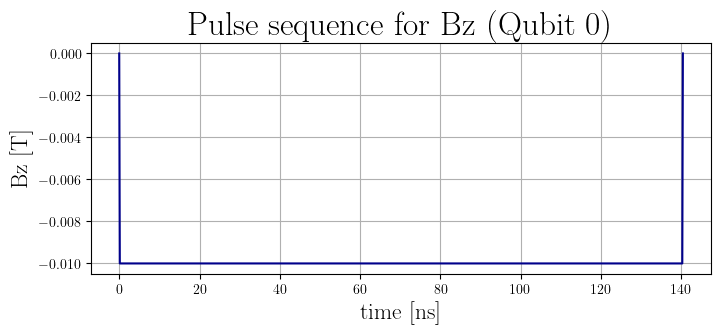

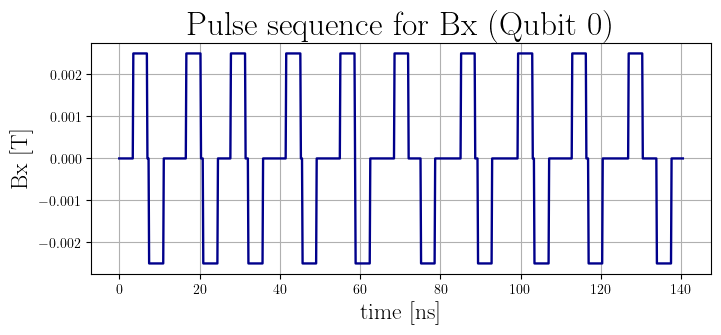

In [11]:
Bp, Jp = plot_pulses_v33_2(dru_circuit, fontsize_axes=17, fontsize_title=24, fontsize_text=9)

In [12]:
Bp, Jp

([[(0, 3.4435534211043172e-09, (0, 0.0, -0.01)),
   (3.4435534211043172e-09, 7.0135450729109e-09, (0.0025, 0.0, -0.01)),
   (7.0135450729109e-09, 7.408925128941957e-09, (0, 0.0, -0.01)),
   (7.408925128941957e-09, 1.0978916780748541e-08, (-0.0025, 0.0, -0.01)),
   (1.0978916780748541e-08, 1.3163173171222285e-08, (0, 0.0, -0.01)),
   (1.3163173171222285e-08, 1.6690435376359002e-08, (0, 0.0, -0.01)),
   (1.6690435376359002e-08, 2.0260427028165584e-08, (0.0025, 0.0, -0.01)),
   (2.0260427028165584e-08, 2.089413321150435e-08, (0, 0.0, -0.01)),
   (2.089413321150435e-08, 2.4464124863310932e-08, (-0.0025, 0.0, -0.01)),
   (2.4464124863310932e-08, 2.772972290402588e-08, (0, 0.0, -0.01)),
   (2.772972290402588e-08, 2.77783838828876e-08, (0, 0.0, -0.01)),
   (2.77783838828876e-08, 3.134837553469418e-08, (0.0025, 0.0, -0.01)),
   (3.134837553469418e-08, 3.213352521197648e-08, (0, 0.0, -0.01)),
   (3.213352521197648e-08, 3.570351686378306e-08, (-0.0025, 0.0, -0.01)),
   (3.570351686378306e-08, 3.

In [13]:
# 2 qubits con entrelazamiento:
X, y =  make_IRIS_v2(3,3)

tf_entanglement = True

model = Modelo_DRU(qcircuit_2_qubit_mixed, fidelity_cost,
                        epochs = 2, n_clases = 3, n_qubits = 2,
                        features = 3, num_layers = 4, alpha_noise = 0.0, val_prc = 0.2,
                        save_process = False, save_w_states = True,
                        entanglement = tf_entanglement )

# splita data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# get optimized parameters
paramters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=1000,
                                     N_qubits = 2,
                                     tf_noise = False,
                                     noise_std = 0.0000,
                                     ket_dru_0 = tensor(basis(2, 0),basis(2, 0)),
                                     save_pulses= True,
                                     J = 1.52e11)

state_dru = dru_circuit.qcircuit_DRU_2_Qubit(paramters_1q,
                                             model.X_val[1],
                                             bias=bias_1q,
                                             entanglement = tf_entanglement)


Epoch: 100%|██████████| 2/2 [00:08<00:00,  4.02s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Processing Unitary key: 0


C:\Users\User\AppData\Local\Temp\ipykernel_2580\546584353.py:86: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(global_time_sim * 1e9, B0_pulses_blue, 'b-', label=r'Real $B_z$', color='darkblue')


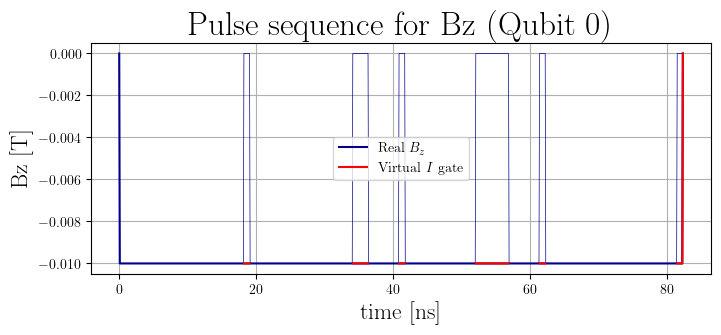

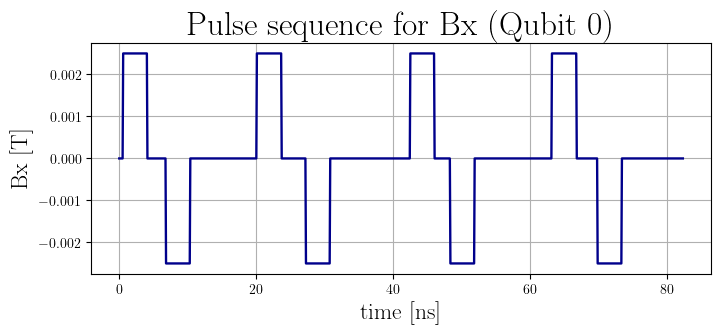

Processing Unitary key: 1


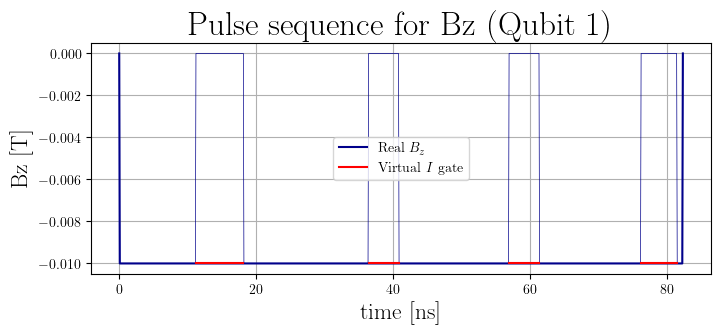

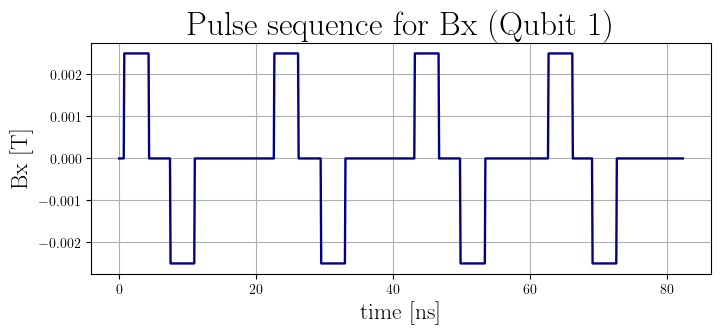

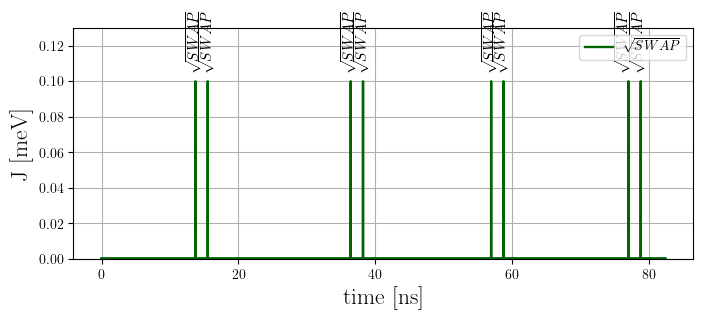

In [14]:
Bp2, Jp2 = plot_pulses_v33_2(dru_circuit, entangl=tf_entanglement, fontsize_axes=17, fontsize_title=24)

In [15]:
Bp2, Jp2

([[(0, 5.251026977983963e-10, (0, 0.0, -0.01)),
   (5.251026977983963e-10, 4.09509434960498e-09, (0.0025, 0.0, -0.01)),
   (4.09509434960498e-09, 6.804657466184362e-09, (0, 0.0, -0.01)),
   (6.804657466184362e-09, 1.0374649117990946e-08, (-0.0025, 0.0, -0.01)),
   (1.0374649117990946e-08, 1.3706868147325899e-08, (0, 0.0, -0.01)),
   (1.3717202333686392e-08, 1.5502198159589685e-08, (0, 0.0, -0.01)),
   (1.5512532345950177e-08, 1.8190026084805115e-08, (0, 0.0, -0.01)),
   (1.9082523997756762e-08, 2.0102599165466264e-08, (0, 0.0, -0.01)),
   (2.0102599165466264e-08, 2.3672590817272846e-08, (0.0025, 0.0, -0.01)),
   (2.3672590817272846e-08, 2.719741867782225e-08, (0, 0.0, -0.01)),
   (2.719741867782225e-08, 3.076741032962883e-08, (-0.0025, 0.0, -0.01)),
   (3.076741032962883e-08, 3.405057486508209e-08, (0, 0.0, -0.01)),
   (3.6400606892134536e-08, 3.818560271803783e-08, (0, 0.0, -0.01)),
   (3.8195936904398326e-08, 4.087343064325326e-08, (0, 0.0, -0.01)),
   (4.176592855620491e-08, 4.24506

# Pulsos con trotterización

In [ ]:
# trotter_vs_exact_time_dependent_fixed.py
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from scipy.linalg import expm

# -----------------------
# Parámetros físicos & sistema
# -----------------------
N = 4                    # número de spins
J_base = 1.0             # escala de acoplamiento
g_L = 1.0                # Landé g-factor
mu_B = 1.0               # Bohr magneton (escala)
total_time = 12.0
n_trotter_steps = 80     # número de pasos Trotter (coarse)
# dt_trot se calcula más abajo desde n_trotter_steps

# dispositivo PennyLane (simulador statevector) para trotter
dev = qml.device("default.qubit", wires=N)

# -----------------------
# Pulsos cuadrados: utilidad para definir señales en el tiempo
# -----------------------
def square_pulse(t, intervals):
    """
    intervals: lista de (t_start, t_end, amplitude)
    devuelve la suma de amplitudes activas en tiempo t
    """
    val = 0.0
    for (t0, t1, amp) in intervals:
        if (t >= t0) and (t < t1):
            val += amp
    return val

# -----------------------
# Definición de pulsos (ejemplo)
# -----------------------
# --- J(t): apagado (sin interacción entre spins)
J_pulse_intervals = [
    (0.0, 12.0, 0.0)
]

# --- Campos locales: pulso en X positivo y luego negativo en todos los sitios
B_pulse_intervals_per_site = [
    [(2.0, 2.4, (3.0, 0.0, 0.0)),   # campo Bx positivo corto
     (7.0, 10.0, (-4.0, 0.0, 0.0))],  # campo Bx negativo más largo
] * N

edge_list = [(i, i+1) for i in range(N-1)]

def J_ij_at_time(i, j, t):
    amp = square_pulse(t, J_pulse_intervals)
    return J_base * amp

def B_i_at_time(i, t):
    intervals = B_pulse_intervals_per_site[i] if i < len(B_pulse_intervals_per_site) else []
    Bx = 0.0; By = 0.0; Bz = 0.0
    for (t0, t1, vec) in intervals:
        if (t >= t0) and (t < t1):
            bx, by, bz = vec
            Bx += bx; By += by; Bz += bz
    return np.array([Bx, By, Bz], dtype=float)

# -----------------------
# Utilidades para construir Hamiltoniano matricial (exacta)
# -----------------------
# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
si = np.eye(2, dtype=complex)

def kron_n(op_list):
    out = op_list[0]
    for op in op_list[1:]:
        out = np.kron(out, op)
    return out

def build_H_matrix_time(t):
    """
    Construye la matriz del Hamiltoniano H(t) = sum_{<i,j>} J_ij(t) S_i·S_j - gL muB sum_i B_i(t)·S_i
    con S = 1/2 sigma.
    """
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    # término interacción S_i·S_j = 1/4 (σxσx + σyσy + σzσz)
    for (i, j) in edge_list:
        Jij = J_ij_at_time(i, j, t)
        if abs(Jij) < 1e-12:
            continue
        for op in (sx, sy, sz):
            ops = [si] * N
            ops[i] = op
            ops[j] = op
            H += (-Jij * 0.25) * kron_n(ops)

    # término Zeeman local: - g_L mu_B B_i · S_i  with S_i = sigma/2
    for i in range(N):
        Bx, By, Bz = B_i_at_time(i, t)
        if abs(Bx) > 1e-12:
            ops = [si] * N
            ops[i] = sx
            H += (-g_L * mu_B * Bx * 0.5) * kron_n(ops)
        if abs(By) > 1e-12:
            ops = [si] * N
            ops[i] = sy
            H += (-g_L * mu_B * By * 0.5) * kron_n(ops)
        if abs(Bz) > 1e-12:
            ops = [si] * N
            ops[i] = sz
            H += (-g_L * mu_B * Bz * 0.5) * kron_n(ops)

    return H

# -----------------------
# Implementación de Trotter (primer orden) en PennyLane
# -----------------------
def apply_two_body_interaction(Jij, dt_local, i, j):
    theta = Jij * dt_local / 2.0
    qml.IsingXX(theta, wires=[i, j])
    qml.IsingYY(theta, wires=[i, j])
    qml.IsingZZ(theta, wires=[i, j])

def apply_local_zeeman(Bvec, dt_local, i, gL=g_L, muB=mu_B):
    Bx, By, Bz = Bvec
    if abs(Bx) > 0:
        qml.RX(-gL * muB * Bx * dt_local, wires=i)
    if abs(By) > 0:
        qml.RY(-gL * muB * By * dt_local, wires=i)
    if abs(Bz) > 0:
        qml.RZ(-gL * muB * Bz * dt_local, wires=i)

@qml.qnode(dev)
def trotter_evolution(n_steps, scheme="first"):
    # Estado inicial: todos down |1>
    for w in range(N):
        qml.PauliX(wires=w)

    dt_trot_local = total_time / n_trotter_steps
    for k in range(n_steps):
        t = (k + 0.5) * dt_trot_local
        # interacciones
        for (i, j) in edge_list:
            Jij = J_ij_at_time(i, j, t)
            if abs(Jij) < 1e-12:
                continue
            apply_two_body_interaction(Jij, dt_trot_local, i, j)
        # Zeeman local
        for i in range(N):
            Bvec = B_i_at_time(i, t)
            if np.allclose(Bvec, 0.0):
                continue
            apply_local_zeeman(Bvec, dt_trot_local, i)

    return [qml.expval(qml.PauliZ(i)) for i in range(N)]

# -----------------------
# Estado inicial (vector) para evolución exacta
# -----------------------
def initial_down_state(N):
    v = np.array([0,1], dtype=complex)   # |1> per qubit (spin down)
    psi = v
    for _ in range(N-1):
        psi = np.kron(psi, v)
    return psi

def local_magnetizations_from_state(psi):
    """Devuelve vector de <Z_j> para el estado psi (matriz completa)."""
    res = np.zeros(N, dtype=float)
    for j in range(N):
        ops = [np.eye(2, dtype=complex)] * N
        ops[j] = sz
        Zj = kron_n(ops)
        res[j] = np.vdot(psi, Zj @ psi).real
    return res

# -----------------------
# Integración exacta en pasos (time-ordered exponential por pasos)
# -----------------------
n_exact_substeps = 100             # subpasos por paso trotter (ajustable)
n_exact_steps = n_trotter_steps * n_exact_substeps
dt_exact = total_time / n_exact_steps
dt_trot = total_time / n_trotter_steps

# tiempos a muestrear para graficar (coinciden con los pasos Trotter)
times_trot = np.linspace(0.0, total_time, n_trotter_steps + 1)

times_exact = np.linspace(0.0, total_time, n_exact_steps + 1)

# --- Calcular pulsos (para plotting)
J_vals = np.array([J_ij_at_time(0, 1, t) for t in times_trot])
Bx_vals = np.zeros((N, len(times_trot)))
for idx, t in enumerate(times_trot):
    for i in range(N):
        Bvec = B_i_at_time(i, t)
        Bx_vals[i, idx] = Bvec[0]

# --- Evolución exacta (alta resolución) muestreada cada paso Trotter
psi_exact = initial_down_state(N)
M_t_exact = [np.mean(local_magnetizations_from_state(psi_exact))]  # lista iniciada en t=0
times_exact_sampled = [0.0]

for k in range(1, n_exact_steps + 1):
    t_mid = (k - 0.5) * dt_exact
    H_mid = build_H_matrix_time(t_mid)
    U = expm(-1j * H_mid * dt_exact)
    psi_exact = U @ psi_exact
    t_curr = k * dt_exact # nuevo
    M_t_exact.append(np.mean(local_magnetizations_from_state(psi_exact))) # nuevo
    times_exact_sampled.append(t_curr) # nuevo
    #if k % n_exact_substeps == 0:
    #    M_t_exact.append(np.mean(local_magnetizations_from_state(psi_exact)))

# --- Evolución trotter (coarse)
psi0 = initial_down_state(N)
M_t_trotter = [np.mean(local_magnetizations_from_state(psi0))]  # t=0

print("Comenzando bucle temporal: se llamará al qnode trotter para cada k y se integrará la evolución exacta por pasos")
for k in range(1, n_trotter_steps + 1):
    # Trotter: ejecutamos qnode con k pasos
    vals = trotter_evolution(k, scheme="first")
    mz_trot = np.mean([float(v) for v in vals])
    M_t_trotter.append(mz_trot)
    if (k % 10) == 0:
        print(f" step {k}/{n_trotter_steps}: t={(k*dt_trot):.3f}  M_trot={mz_trot:.4f}")

# --- Convertir listas a arrays (ahora que ya no usamos append)
M_t_exact = np.array(M_t_exact)
times_exact_sampled = np.array(times_exact_sampled)

M_t_trotter = np.array(M_t_trotter)

# -----------------------
# Graficar: pulsos vs magnetización comparación
# -----------------------
fig, (ax_pulses, ax_mag) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                         gridspec_kw={'height_ratios': [1, 1.1]})

# Pulsos: J(t)
ax_pulses.plot(times_trot, J_vals, label='J(t) (global)', color='tab:gray', linewidth=2)

# Pulsos: Bx por sitio
colors = plt.cm.viridis(np.linspace(0, 1, N))
for i in range(N):
    ax_pulses.plot(times_trot, Bx_vals[i], '--', label=f'Bx site {i}', color=colors[i])

ax_pulses.set_ylabel('Pulse amplitude')
ax_pulses.set_title('Pulsos en tiempo: J(t) y Bx^{(i)}(t)')
ax_pulses.legend(loc='upper right', fontsize='small', ncol=2)
ax_pulses.grid(True)

# Magnetización: comparar exact vs trotter
ax_mag.plot(times_exact_sampled, M_t_exact, '-', color='k', lw=1.5, label='exact (fine Δt, muestreada)')
ax_mag.plot(times_trot, M_t_trotter, 'o--', color='tab:red', label='trotter (coarse Δt)')
ax_mag.set_xlabel('t')
ax_mag.set_ylabel('M(t) = (1/N) Σ ⟨Z_j⟩')
ax_mag.set_title('Magnetización total (Exacta vs Trotter)')
ax_mag.grid(True)
ax_mag.legend()

plt.tight_layout()
plt.show()


# Pipeline integrado

In [4]:
# from oficial python
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch
from matplotlib import cm
import matplotlib as mpl
from qutip import basis, tensor
import time
from sklearn.model_selection import train_test_split
import pennylane as qml
import os
import pandas as pd

# own modules:
from dll.spin_procesor_modificated import Quantum_Spin_Proces
from dll.main_fun import make_IRIS_v2, pulse_x_with_noise, pulse_x, pulse_z
from dll. baseline_dru_v2 import Modelo_DRU
from dll.models import qcircuit_1_qubit_mixed, qcircuit_2_qubit_mixed, qcircuit_4_qubit_mixed
from dll.cost_functions import fidelity_cost
from dll.gate_procesor_modificated import CompositeGateProcessor

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNCIONES AUXILIARES (Intactas)
# ==========================================

def make_total_pulse(values):
    """
    Separa el pulso en parte Real (activa) y parte Virtual (gaps/ceros).
    """
    values = np.array(values, dtype=float)
    mask = np.isclose(values, 0.0, atol=1e-12)
    
    real_part = np.copy(values)
    real_part[mask] = np.nan 
    
    virtual_part = np.copy(values)
    virtual_part[~mask] = np.nan 
    
    return real_part, virtual_part

def _intervals_to_dense(intervals, total_time, num_points=1000):
    t_dense = np.linspace(0, total_time, num_points)
    y_dense = np.zeros_like(t_dense)
    for (t0, t1, amp, _) in intervals:
        mask = (t_dense >= t0) & (t_dense < t1)
        y_dense[mask] += amp
    return t_dense, y_dense

# ==========================================
# 2. MOTOR DE EXTRACCIÓN (REINGENIERÍA TOTAL)
# ==========================================

def extract_pulses_data(processor_obj):
    """
    Extrae los pulsos activos y DETECTA AUTOMÁTICAMENTE LOS GAPS (Virtual I Gates)
    reconstruyendo la línea de tiempo de cada qubit.
    """
    global_time = processor_obj.global_time
    pulse_data = {
        'sites': {},
        'edges': {},
        'total_time': global_time,
        'virtual_metadata': [] 
    }

    # 1. Inicializar estructura y contenedores temporales
    # temp_active_pulses guardará: { qubit_id: [ {t_i, t_f, B0, B1, B2}, ... ] }
    temp_active_pulses = {}
    
    for i in range(processor_obj.N_qubits):
        pulse_data['sites'][i] = {'Bx': [], 'By': [], 'Bz': []}
        temp_active_pulses[i] = []

    raw_data = processor_obj.pulse_type
    
    # 2. Primera pasada: Recolectar SOLO pulsos activos explícitos
    for key in raw_data:
        list_pulses = raw_data[key]
        if not list_pulses: continue
        
        type_pulse = list_pulses[0].get('Type_pulse', 'Unitary')

        if type_pulse == 'Unitary':
            # Identificar Qubit
            try:
                qubit_idx = int(key) if isinstance(key, int) or key.isdigit() else 0
            except:
                qubit_idx = 0
            
            if qubit_idx not in temp_active_pulses:
                temp_active_pulses[qubit_idx] = [] # Safety init

            for p in list_pulses:
                # Guardamos el diccionario crudo temporalmente
                temp_active_pulses[qubit_idx].append(p)

        elif type_pulse == 'Two_Qubits':
            # Lógica de interacción (sin cambios)
            q0 = list_pulses[0].get('q0', 0)
            q1 = list_pulses[0].get('q1', 1)
            q_pair = (q0, q1)
            if q_pair not in pulse_data['edges']: pulse_data['edges'][q_pair] = {'J': []}
            for p in list_pulses:
                t_i, t_f, J_val = p['t_i'], p['t_f'], p.get('J', 0.0)
                pulse_data['edges'][q_pair]['J'].append((t_i, t_f, J_val, "Interaction"))

    # 3. Segunda pasada: Reconstruir Timeline por Qubit y Detectar Gaps
    for q_idx in range(processor_obj.N_qubits):
        # Obtener lista de pulsos activos y ORDENARLOS por tiempo de inicio
        # Esto es crucial para detectar huecos secuencialmente
        qubit_pulses = sorted(temp_active_pulses[q_idx], key=lambda x: x['t_i'])
        
        current_time = 0.0
        
        for p in qubit_pulses:
            t_start = p['t_i']
            t_end = p['t_f']
            
            # A. DETECCIÓN DE GAP (VIRTUAL I GATE) ANTES DEL PULSO ACTUAL
            # Si el pulso empieza después del tiempo actual, hay un hueco
            if t_start > current_time + 1e-13: # Tolerancia pequeña
                # Crear Metadata de Virtual Gate
                gap_duration = t_start - current_time
                virtual_info = {
                    'qubit': q_idx,
                    't_i': current_time,
                    't_f': t_start,
                    'duration': gap_duration,
                    'amp_x': 0.0, 'amp_y': 0.0, 'amp_z': 0.0,
                    'note': 'Detected Gap'
                }
                pulse_data['virtual_metadata'].append(virtual_info)
                
                # Agregar explícitamente como intervalos 0 a los datos de ploteo
                # Esto asegura que el plot tenga continuidad explícita
                pulse_data['sites'][q_idx]['Bz'].append((current_time, t_start, 0.0, "Virtual_I"))
                pulse_data['sites'][q_idx]['Bx'].append((current_time, t_start, 0.0, "Virtual_I"))
                pulse_data['sites'][q_idx]['By'].append((current_time, t_start, 0.0, "Virtual_I"))

            # B. REGISTRAR EL PULSO ACTIVO ACTUAL
            b0 = p.get('B0', 0.0)
            b1 = p.get('B1', 0.0)
            b2 = p.get('B2', 0.0)
            
            pulse_data['sites'][q_idx]['Bz'].append((t_start, t_end, b0, "Active"))
            pulse_data['sites'][q_idx]['Bx'].append((t_start, t_end, b1, "Active"))
            pulse_data['sites'][q_idx]['By'].append((t_start, t_end, b2, "Active"))
            
            # Actualizar cursor de tiempo
            # Usamos max por si hay pulsos solapados (raro en control cuántico puro, pero posible en simulación)
            current_time = max(current_time, t_end)
        
        # C. DETECCIÓN DE GAP FINAL (TAIL)
        # Si el último pulso terminó antes del tiempo global de simulación
        if current_time < global_time - 1e-13:
            virtual_info = {
                'qubit': q_idx,
                't_i': current_time,
                't_f': global_time,
                'duration': global_time - current_time,
                'amp_x': 0.0, 'amp_y': 0.0, 'amp_z': 0.0,
                'note': 'Final Wait'
            }
            pulse_data['virtual_metadata'].append(virtual_info)
            
            pulse_data['sites'][q_idx]['Bz'].append((current_time, global_time, 0.0, "Virtual_I"))
            pulse_data['sites'][q_idx]['Bx'].append((current_time, global_time, 0.0, "Virtual_I"))
            pulse_data['sites'][q_idx]['By'].append((current_time, global_time, 0.0, "Virtual_I"))

    return pulse_data

# ==========================================
# 3. MOTOR DE VISUALIZACIÓN (Intacto pero funcional con nueva data)
# ==========================================

def plot_pulse_structure(pulse_data, fontsize_title=14, fontsize_axes=12, save_path=None):
    """
    Grafica los pulsos: Bz (Real vs Virtual), Bx y J Interactions.
    """
    total_time = pulse_data['total_time']
    
    # A. Graficar Single Qubits
    for q_id, fields in pulse_data['sites'].items():
        if not fields['Bz'] and not fields['Bx']: continue

        t_vec, bz_vec = _intervals_to_dense(fields['Bz'], total_time)
        _, bx_vec = _intervals_to_dense(fields['Bx'], total_time)
        
        # Plot Bz
        # make_total_pulse funcionará perfecto porque ahora tenemos intervalos de 0 explícitos
        bz_real, bz_virtual = make_total_pulse(bz_vec)
        
        plt.figure(figsize=(8, 3))
        plt.plot(t_vec * 1e9, bz_vec, linewidth=0.5, color='darkblue', alpha=0.3)
        plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)
        plt.plot(t_vec * 1e9, bz_virtual, 'r-', label=r'Virtual $I$ gate', linewidth=1.5)
        
        plt.title(f"Pulse sequence for Bz (Qubit {q_id})", fontsize=fontsize_title)
        plt.xlabel("time [ns]", fontsize=fontsize_axes)
        plt.ylabel("Bz [T]", fontsize=fontsize_axes)
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right')
        if save_path: plt.savefig(os.path.join(save_path, f"Bz_Q{q_id}.pdf"), bbox_inches='tight')
        plt.show()

        # Plot Bx
        if np.any(np.abs(bx_vec) > 0):
            plt.figure(figsize=(8, 3))
            plt.plot(t_vec * 1e9, bx_vec, linewidth=1.7, color='darkblue')
            plt.title(f"Pulse sequence for Bx (Qubit {q_id})", fontsize=fontsize_title)
            plt.xlabel("time [ns]", fontsize=fontsize_axes)
            plt.ylabel("Bx [T]", fontsize=fontsize_axes)
            plt.grid(True, alpha=0.3)
            if save_path: plt.savefig(os.path.join(save_path, f"Bx_Q{q_id}.pdf"), bbox_inches='tight')
            plt.show()

    # B. Graficar J couplings (Igual que antes)
    for pair, data in pulse_data['edges'].items():
        intervals = data['J']
        if not intervals: continue
        
        t_vec, j_vec = _intervals_to_dense(intervals, total_time, num_points=2000)
        fig, ax = plt.subplots(figsize=(8, 3))
        
        swap_color, sqrt_swap_color, other_color = 'darkblue', 'darkgreen', 'gray'
        ax.plot(t_vec * 1e9, j_vec, linewidth=1.0, color='black', alpha=0.2)
        
        processed_intervals = [] 
        for (t_i, t_f, J_val, _) in intervals:
            if abs(J_val) < 1e-12: continue
            
            duration = t_f - t_i
            Swap_time = np.pi / J_val if J_val != 0 else np.inf
            sqrt_Swap_time = np.pi / (2 * J_val) if J_val != 0 else np.inf
            
            label = "Unknown"; color = other_color
            if abs(duration - Swap_time) < 1e-10: label = "SWAP"; color = swap_color
            elif abs(duration - sqrt_Swap_time) < 1e-10: label = r"$\sqrt{SWAP}$"; color = sqrt_swap_color
            
            t_segment = np.linspace(t_i, t_f, 100)
            ax.plot(t_segment * 1e9, [J_val]*100, linewidth=2.0, color=color, 
                    label=label if label not in processed_intervals else "")
            
            if label not in processed_intervals: processed_intervals.append(label)
            
            y_text = J_val * 1.05
            ax.text((t_f + t_i)/2 * 1e9, y_text, label, ha='center', va='bottom', rotation=90, fontsize=10, color=color)

        ax.set_title(f"Interaction Pulse J for Qubits {pair}", fontsize=fontsize_title)
        ax.set_xlabel("time [ns]", fontsize=fontsize_axes)
        ax.set_ylabel("J", fontsize=fontsize_axes)
        if np.max(j_vec) > 0: ax.set_ylim([0, np.max(j_vec) * 1.4])
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        if save_path: plt.savefig(os.path.join(save_path, f"J_Interaction_{pair}.pdf"), bbox_inches='tight')
        plt.show()

# ==========================================
# 4. FUNCIÓN PRINCIPAL WRAPPER
# ==========================================

def extract_and_plot_pulses(processor_obj, plot=True, verbose=0, save_path="results"):
    pulse_data = extract_pulses_data(processor_obj)
    
    if verbose > 0:
        n_virtual = len(pulse_data['virtual_metadata'])
        print(f"[INFO] Datos extraídos para {len(pulse_data['sites'])} qubits.")
        print(f"[INFO] Virtual I Gates detectadas y guardadas: {n_virtual}")
        print(f"[INFO] Tiempo total simulación: {pulse_data['total_time']:.2e} s")
    
    if plot:
        if save_path and not os.path.exists(save_path):
            os.makedirs(save_path)
        plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
        plot_pulse_structure(pulse_data, save_path=save_path)
        
    return pulse_data

In [32]:
# 1. Configuración de datos y modelo (INTACTO del original)
X, y = make_IRIS_v2(3,3)

# Nota: N_qubits = 1 en este ejemplo, pero el código soporta N > 1
N_QUBITS_SIM = 1 

model = Modelo_DRU(qcircuit_1_qubit_mixed, fidelity_cost,
                    epochs=5, n_clases=3, n_qubits=N_QUBITS_SIM,
                    features=3, num_layers=10, alpha_noise=0.0, val_prc=0.2,
                    save_process=False, save_w_states=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
parameters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

# 2. Generación del Circuito y Pulsos
dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=100,
                                      N_qubits=N_QUBITS_SIM,
                                      tf_noise=False,
                                      noise_std=0.0000, 
                                      save_pulses=True,
                                      J=1.52e11)

# Simular paso para generar los pulsos internos
state_dru = dru_circuit.qcircuit_DRU_1_Qubit(parameters_1q,
                                              model.X_val[1],
                                              bias=bias_1q)

Epoch: 100%|██████████| 5/5 [00:23<00:00,  4.68s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


[INFO] Datos extraídos para 1 qubits.
[INFO] Virtual I Gates detectadas y guardadas: 0
[INFO] Tiempo total simulación: 1.40e-07 s


C:\Users\User\AppData\Local\Temp\ipykernel_6964\3420889074.py:178: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)


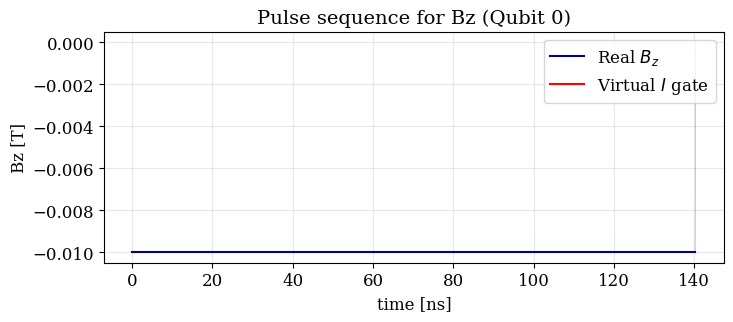

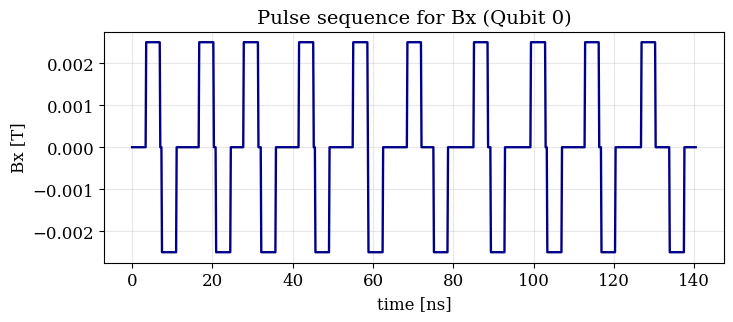

In [33]:
# Define una carpeta para guardar resultados
path_resultados = "mis_resultados_experimentales/test_01"

# La función creará la carpeta si no existe
pulse_data = extract_and_plot_pulses(
    dru_circuit, 
    plot=True, 
    verbose=1,            # Te imprimirá info sobre duración y qubits detectados
    save_path=path_resultados 
)

In [34]:
# 2 qubits con entrelazamiento:
X, y =  make_IRIS_v2(3,3)

tf_entanglement = True
N_QUBITS_SIM = 2

model = Modelo_DRU(qcircuit_2_qubit_mixed, fidelity_cost,
                        epochs = 2, n_clases = 3, n_qubits = N_QUBITS_SIM,
                        features = 3, num_layers = 4, alpha_noise = 0.0, val_prc = 0.2,
                        save_process = False, save_w_states = True,
                        entanglement = tf_entanglement )

# splita data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# get optimized parameters
paramters_1q, bias_1q = model.fit(X_train, y_train, X_test, y_test)

dru_circuit = CompositeGateProcessor(n_points_pulse_Ri=1000,
                                     N_qubits = N_QUBITS_SIM,
                                     tf_noise = False,
                                     noise_std = 0.0000,
                                     ket_dru_0 = tensor(basis(2, 0),basis(2, 0)),
                                     save_pulses= True,
                                     J = 1.52e11)

state_dru = dru_circuit.qcircuit_DRU_2_Qubit(paramters_1q,
                                             model.X_val[1],
                                             bias=bias_1q,
                                             entanglement = tf_entanglement)

Epoch: 100%|██████████| 2/2 [00:08<00:00,  4.36s/it]
c:\Users\User\Desktop\codigos_tesis_maestria\QML_with_spins_using_DRU_algorithm\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


[INFO] Datos extraídos para 2 qubits.
[INFO] Virtual I Gates detectadas y guardadas: 16
[INFO] Tiempo total simulación: 8.23e-08 s


C:\Users\User\AppData\Local\Temp\ipykernel_6964\3420889074.py:178: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)


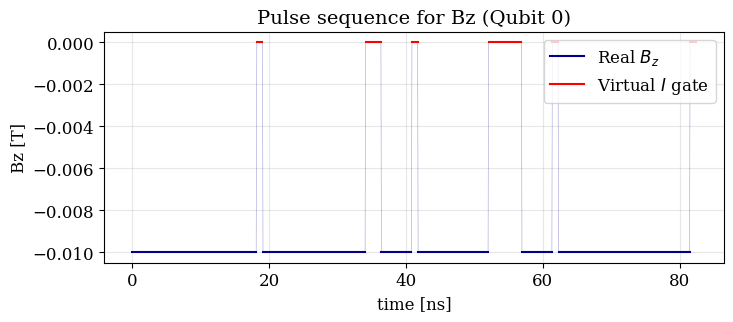

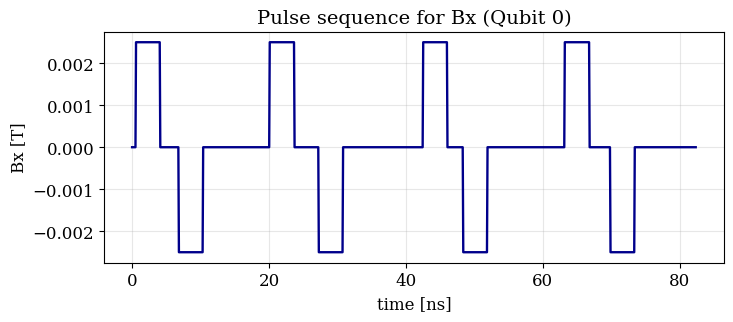

C:\Users\User\AppData\Local\Temp\ipykernel_6964\3420889074.py:178: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(t_vec * 1e9, bz_real, 'b-', label=r'Real $B_z$', color='darkblue', linewidth=1.5)


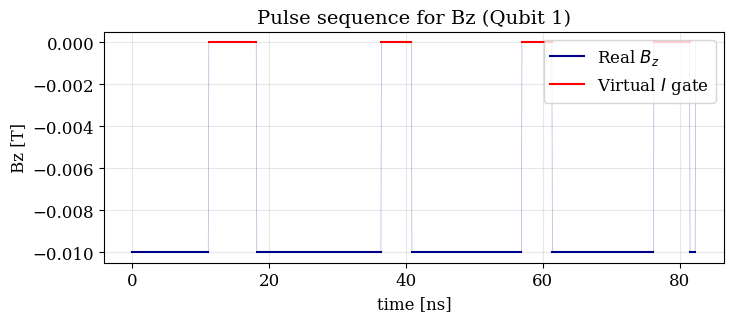

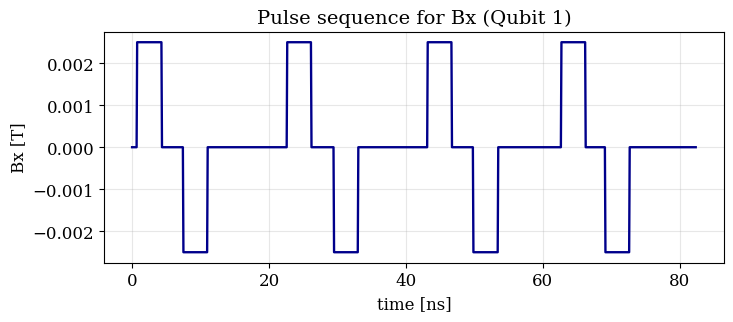

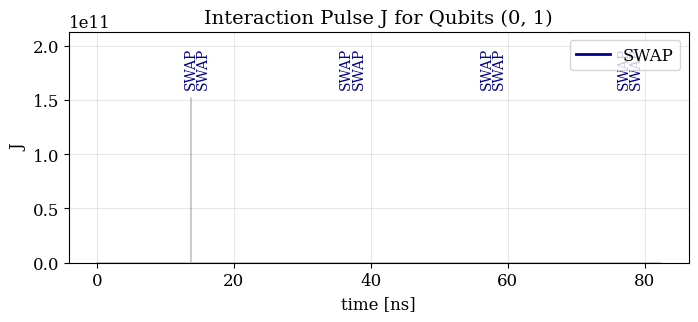

In [35]:
# Define una carpeta para guardar resultados
path_resultados = "mis_resultados_experimentales/test_02"

# La función creará la carpeta si no existe
pulse_data = extract_and_plot_pulses(
    dru_circuit, 
    plot=True, 
    verbose=1,            # Te imprimirá info sobre duración y qubits detectados
    save_path=path_resultados 
)

In [36]:
pulse_data

{'sites': {0: {'Bx': [(0, 5.251026977983963e-10, 0, 'Active'),
    (5.251026977983963e-10, 4.09509434960498e-09, 0.0025, 'Active'),
    (4.09509434960498e-09, 6.804657466184362e-09, 0, 'Active'),
    (6.804657466184362e-09, 1.0374649117990946e-08, -0.0025, 'Active'),
    (1.0374649117990946e-08, 1.3706868147325899e-08, 0, 'Active'),
    (1.3706868147325899e-08, 1.3717202333686392e-08, 0.0, 'Virtual_I'),
    (1.3717202333686392e-08, 1.5502198159589685e-08, 0, 'Active'),
    (1.5502198159589685e-08, 1.5512532345950177e-08, 0.0, 'Virtual_I'),
    (1.5512532345950177e-08, 1.8190026084805115e-08, 0, 'Active'),
    (1.8190026084805115e-08, 1.9082523997756762e-08, 0.0, 'Virtual_I'),
    (1.9082523997756762e-08, 2.0102599165466264e-08, 0, 'Active'),
    (2.0102599165466264e-08, 2.3672590817272846e-08, 0.0025, 'Active'),
    (2.3672590817272846e-08, 2.719741867782225e-08, 0, 'Active'),
    (2.719741867782225e-08, 3.076741032962883e-08, -0.0025, 'Active'),
    (3.076741032962883e-08, 3.405057486

In [15]:
print(f"Pulsos extraídos. Duración total: {pulse_data['total_time']:.2e} s")
print(f"Metadata de intervalos para Qubit 0 (Bz):")
for interval in pulse_data['sites'][0]['Bz'][:5]: # Mostrar primeros 5
    print(f"  t: [{interval[0]:.2e}, {interval[1]:.2e}], Amp: {interval[2]:.2f}, Tipo: {interval[3]}")

Pulsos extraídos. Duración total: 8.23e-08 s
Metadata de intervalos para Qubit 0 (Bz):
  t: [0.00e+00, 5.25e-10], Amp: -0.01, Tipo: Active
  t: [5.25e-10, 4.10e-09], Amp: -0.01, Tipo: Active
  t: [4.10e-09, 6.80e-09], Amp: -0.01, Tipo: Active
  t: [6.80e-09, 1.04e-08], Amp: -0.01, Tipo: Active
  t: [1.04e-08, 1.37e-08], Amp: -0.01, Tipo: Active


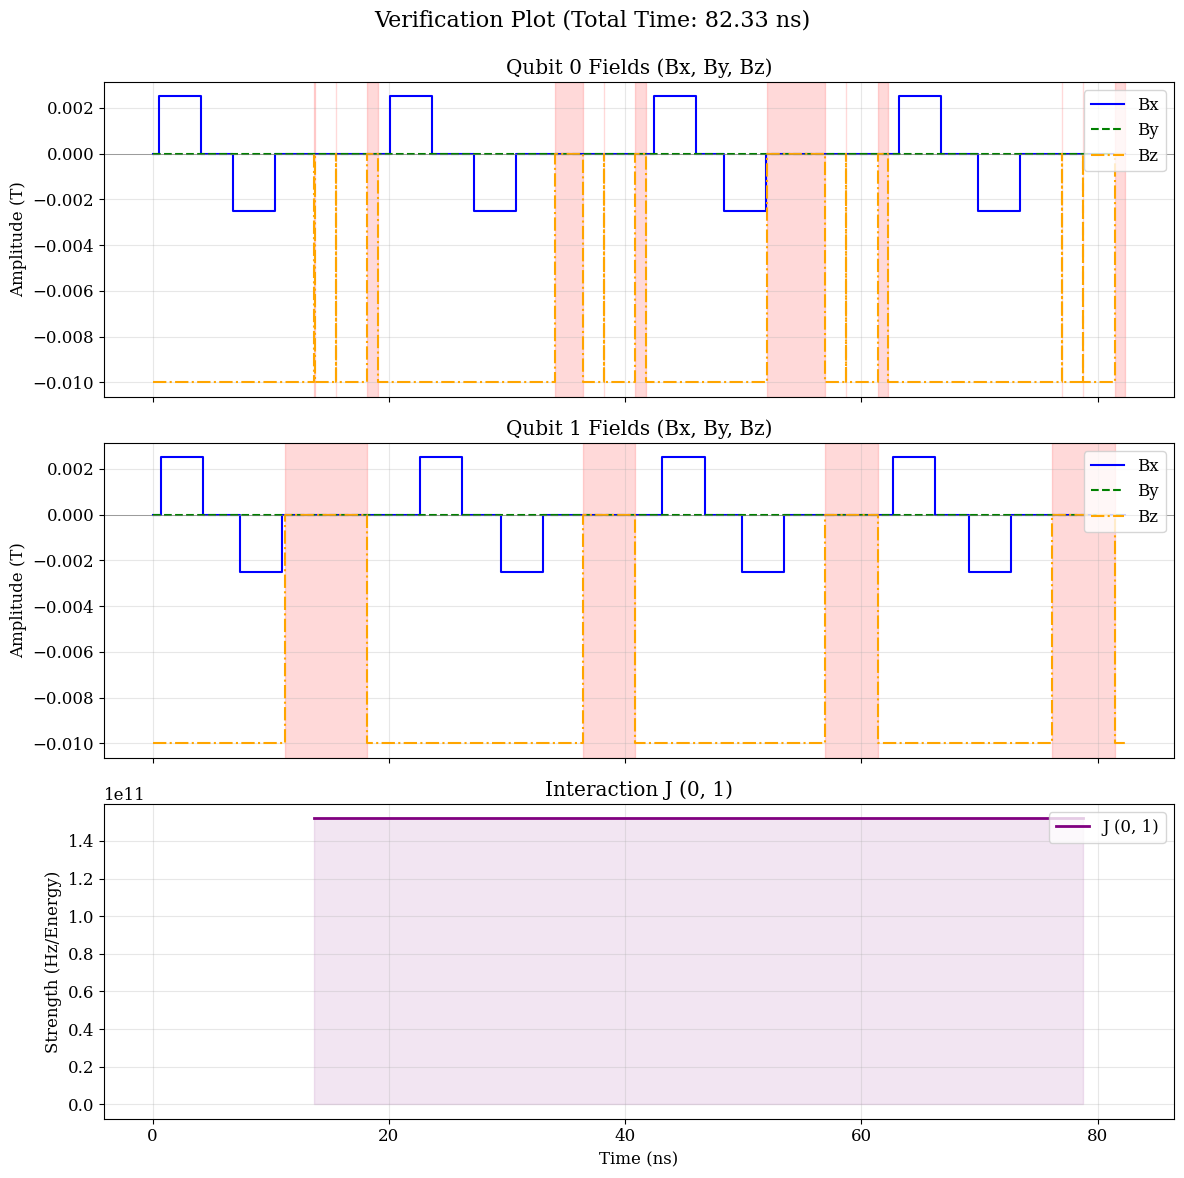

In [38]:
def verify_and_plot_data(pulse_data):
    # Configuración de Subplots
    n_qubits = len(pulse_data['sites'])
    n_edges = len(pulse_data['edges'])
    total_subplots = n_qubits + n_edges
    
    fig, axes = plt.subplots(total_subplots, 1, figsize=(12, 4 * total_subplots), sharex=True)
    if total_subplots == 1: axes = [axes] # Asegurar que sea iterable
    
    # Factor de escala para Tiempo (nanosegundos)
    time_scale = 1e9 
    
    # -----------------------------------
    # 1. Graficar Campos por Qubit (Sites)
    # -----------------------------------
    for i in range(n_qubits):
        ax = axes[i]
        site_data = pulse_data['sites'][i]
        
        # Iterar sobre tipos de campo (Bx, By, Bz)
        colors = {'Bx': 'blue', 'By': 'green', 'Bz': 'orange'}
        styles = {'Bx': '-', 'By': '--', 'Bz': '-.'}
        
        for field_name, intervals in site_data.items():
            if not intervals: continue
            
            # Construir arrays para graficar (Steps rectangulares)
            times = []
            amps = []
            
            for (t0, t1, amp, type_gate) in intervals:
                # Punto inicial del intervalo
                times.append(t0 * time_scale)
                amps.append(amp)
                # Punto final del intervalo
                times.append(t1 * time_scale)
                amps.append(amp)
                
                # Si es Virtual_I, sombreamos el área
                if type_gate == 'Virtual_I' and field_name == 'Bz': # Solo sombreamos una vez (usando Bz como referencia)
                    ax.axvspan(t0 * time_scale, t1 * time_scale, color='red', alpha=0.15, label='_nolegend_')

            # Graficar
            ax.plot(times, amps, label=f'{field_name}', color=colors.get(field_name, 'black'), 
                    linestyle=styles.get(field_name, '-'), linewidth=1.5)
            
            # Dibujar línea cero
            ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)

        ax.set_title(f'Qubit {i} Fields (Bx, By, Bz)')
        ax.set_ylabel('Amplitude (T)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    # -----------------------------------
    # 2. Graficar Interacciones (Edges)
    # -----------------------------------
    for j, (pair, edge_data) in enumerate(pulse_data['edges'].items()):
        ax = axes[n_qubits + j]
        intervals = edge_data['J']
        
        times = []
        amps = []
        
        # Procesar intervalos de interacción
        for (t0, t1, amp, type_gate) in intervals:
            times.append(t0 * time_scale)
            amps.append(amp)
            times.append(t1 * time_scale)
            amps.append(amp)
            
            # Hack visual: Si el intervalo es muy corto (delta), graficar un punto o línea vertical
            if (t1 - t0) < 1e-13: 
                ax.plot([(t0+t1)/2 * time_scale], [amp], 'x', color='purple')

        ax.plot(times, amps, label=f'J {pair}', color='purple', linewidth=2)
        ax.fill_between(times, amps, 0, color='purple', alpha=0.1)
        
        ax.set_title(f'Interaction J {pair}')
        ax.set_ylabel('Strength (Hz/Energy)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    # Configuración final
    plt.xlabel('Time (ns)')
    plt.suptitle(f"Verification Plot (Total Time: {pulse_data['total_time']*1e9:.2f} ns)", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Espacio para el título principal
    plt.show()

# Ejecutar la verificación
verify_and_plot_data(pulse_data)

# ----

Simulando 2 qubits por 8.23e-08 s en 500 pasos...


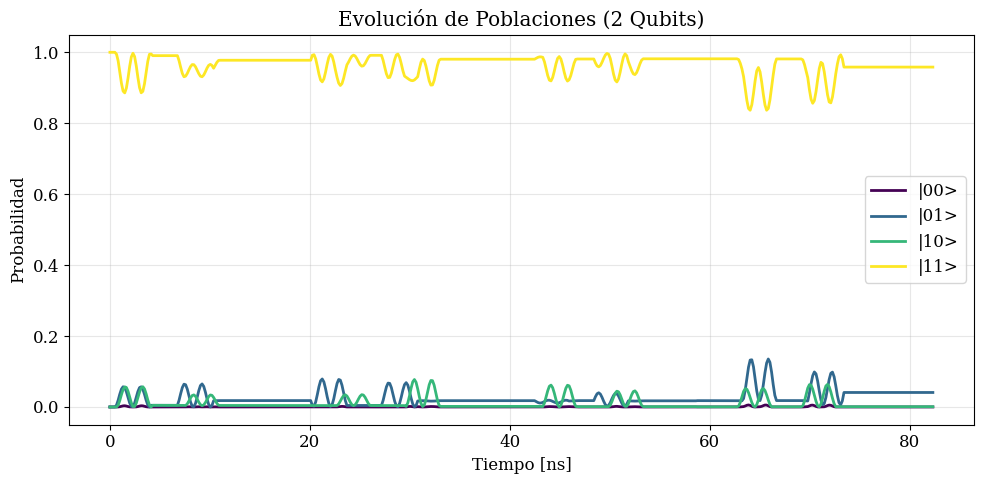

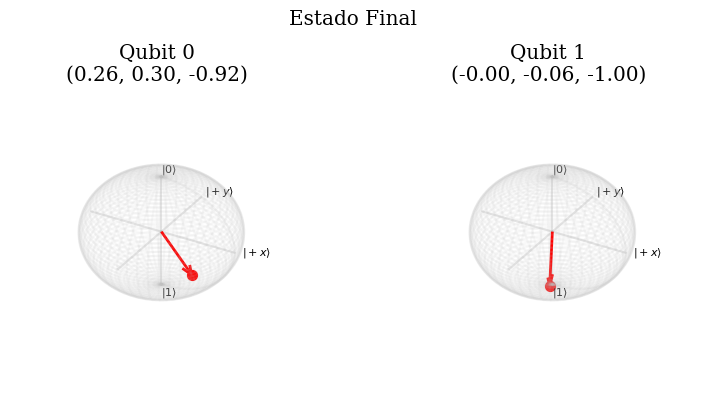

In [48]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. CONSTANTES FÍSICAS Y AJUSTES DE ESCALA
# ==========================================
# Ajustamos las constantes para que las unidades (Teslas y Segundos) 
# produzcan rotaciones visibles en la esfera de Bloch.

CONSTANTS = {
    # Relación giromagnética del electrón aprox: ~1.76e11 rad/(s*T).
    # Usamos esto para convertir B(Tesla) * t(segundos) a radianes.
    'gamma': 1.76e11, 
    
    # Factor para J. Si J ya está en Hz (1/s), lo multiplicamos por 2pi para radianes
    # Si J es muy rápido (1e11), necesitamos muchos pasos Trotter.
    'J_factor': 2 * np.pi 
}

def get_pulse_value(t, intervals_list):
    """Busca el valor del pulso en el tiempo t dado una lista de intervalos."""
    for (t0, t1, amp, _) in intervals_list:
        if t0 <= t < t1:
            return amp
    return 0.0

def _draw_bloch_sphere(ax):
    """Dibuja la estructura de alambre de la esfera de Bloch."""
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x, y, z, color="silver", alpha=0.1)
    ax.plot([-1, 1], [0, 0], [0, 0], 'k-', alpha=0.1) 
    ax.plot([0, 0], [-1, 1], [0, 0], 'k-', alpha=0.1) 
    ax.plot([0, 0], [0, 0], [-1, 1], 'k-', alpha=0.1)
    ax.text(1.1, 0, 0, "$|+x\\rangle$", fontsize=8)
    ax.text(0, 1.1, 0, "$|+y\\rangle$", fontsize=8)
    ax.text(0, 0, 1.1, "$|0\\rangle$", fontsize=8)
    ax.text(0, 0, -1.2, "$|1\\rangle$", fontsize=8)
    ax.set_axis_off()

# ==========================================
# 2. MOTOR DE SIMULACIÓN (TROTTER)
# ==========================================

def run_simulation_population(pulse_data, n_qubits, n_trotter_steps=200):
    """
    Ejecuta la simulación Trotter.
    NOTA: Aumentar n_trotter_steps es crucial si J es muy grande.
    """
    total_time = pulse_data['total_time']
    times_trot = np.linspace(0.0, total_time, n_trotter_steps + 1)
    
    dev = qml.device("default.qubit", wires=n_qubits)
    
    # Función auxiliar para J
    def J_ij_at_time(i, j, t):
        pair = (min(i,j), max(i,j))
        if pair in pulse_data['edges']:
            edge_data = pulse_data['edges'][pair]
            if 'J' in edge_data:
                val = get_pulse_value(t, edge_data['J'])
                # Convertimos frecuencia a velocidad angular
                return val * CONSTANTS['J_factor'] 
        return 0.0

    # Función auxiliar para Campo B
    def B_i_at_time(i, t):
        if i in pulse_data['sites']:
            bx = get_pulse_value(t, pulse_data['sites'][i]['Bx'])
            bz = get_pulse_value(t, pulse_data['sites'][i]['Bz'])
            # Retornamos vector de campo magnético en Teslas
            return np.array([bx, 0.0, bz]) 
        return np.array([0.0, 0.0, 0.0])

    def apply_trotter_step(dt_local, t_current):
        # NOTA IMPORTANTE:
        # En física: Angulo = FrecuenciaAngular * tiempo
        # Para B: FrecuenciaAngular = gamma * B
        
        # 1. Interacciones J (Ising XX+YY+ZZ)
        for (i, j) in pulse_data['edges'].keys():
            # J_val ya incluye el factor 2pi si es necesario
            omega_J = J_ij_at_time(i, j, t_current) 
            
            # Si J es muy grande (1e11), omega_J * dt será enorme (> 2pi).
            # Esto causa aliasing visual si no hay suficientes pasos.
            # Para visualizar mejor la dinamica B, a veces conviene reducir J artificialmente
            # o aumentar drásticamente los pasos.
            
            if abs(omega_J) > 1e-5:
                # El Hamiltoniano de intercambio suele ser H = J * (XX+YY+ZZ)
                # La rotación es exp(-i * H * t)
                theta = omega_J * dt_local 
                qml.IsingXX(theta, wires=[i, j])
                qml.IsingYY(theta, wires=[i, j])
                qml.IsingZZ(theta, wires=[i, j])
        
        # 2. Campos Locales (Zeeman)
        for i in range(n_qubits):
            bx, by, bz = B_i_at_time(i, t_current)
            
            # Calculamos rotación física: theta = gamma * B * dt
            # Factor -2 es porque qml.RX(theta) rota por theta/2 en la esfera de Bloch (spin 1/2)
            # o dependiendo de la convención de Pauli. Usualmente: R_P(phi) = exp(-i phi P / 2).
            # Evolución temporal: exp(-i H t). Si H = omega * S_z = omega * (sigma_z / 2).
            # Entonces el argumento para RZ es 2 * omega * t_local.
            
            # Usamos CONSTANTS['gamma'] para escalar
            theta_x = CONSTANTS['gamma'] * bx * dt_local
            theta_z = CONSTANTS['gamma'] * bz * dt_local
            
            if abs(theta_x) > 1e-10: qml.RX(2 * theta_x, wires=i) # Factor 2 para compensar Pauli/2
            if abs(theta_z) > 1e-10: qml.RZ(2 * theta_z, wires=i)

    # --- QNodes ---
    @qml.qnode(dev)
    def qnode_probs(target_time, steps):
        # Estado inicial: |11...1> (Spin Down)
        # Si quieres empezar en |00...0> (Spin Up), comenta estas líneas
        for w in range(n_qubits):
            qml.PauliX(wires=w) 

        if steps > 0:
            dt = target_time / steps
            for k in range(steps):
                t = (k + 0.5) * dt
                apply_trotter_step(dt, t)
            
        return qml.probs(wires=range(n_qubits))

    @qml.qnode(dev)
    def qnode_bloch_final(target_time, steps):
        # Mismo estado inicial
        for w in range(n_qubits):
            qml.PauliX(wires=w)

        if steps > 0:
            dt = target_time / steps
            for k in range(steps):
                t = (k + 0.5) * dt
                apply_trotter_step(dt, t)
        
        observables = []
        for i in range(n_qubits):
            observables.append(qml.expval(qml.PauliX(i)))
            observables.append(qml.expval(qml.PauliY(i)))
            observables.append(qml.expval(qml.PauliZ(i)))
        return observables

    # --- Ejecución ---
    print(f"Simulando {n_qubits} qubits por {total_time:.2e} s en {n_trotter_steps} pasos...")
    
    probs_history = []
    # Calculamos probabilidades
    for k, t_curr in enumerate(times_trot):
        # Usamos k pasos para llegar al tiempo t_curr
        # Nota: Esto es ineficiente (re-calcula todo desde 0 cada vez), 
        # pero necesario en PennyLane si no se usa snapshotting.
        p_t = qnode_probs(t_curr, k)
        probs_history.append(p_t)
        
    probs_history = np.array(probs_history)

    # Calculamos Bloch final
    final_obs = qnode_bloch_final(total_time, n_trotter_steps)
    final_obs_vals = [float(v) for v in final_obs]
    
    bloch_vectors = []
    for i in range(n_qubits):
        bx = final_obs_vals[i*3]
        by = final_obs_vals[i*3 + 1]
        bz = final_obs_vals[i*3 + 2]
        bloch_vectors.append((bx, by, bz))

    return times_trot, probs_history, bloch_vectors

# ==========================================
# 3. VISUALIZACIÓN
# ==========================================

def plot_population_dynamics(times, probs_history, n_qubits):
    """Grafica probabilidad de poblaciones."""
    n_states = 2**n_qubits
    plt.figure(figsize=(10, 5))
    
    # Etiquetas binarias
    state_labels = [f"|{bin(i)[2:].zfill(n_qubits)}>" for i in range(n_states)]
    colors = plt.cm.viridis(np.linspace(0, 1, n_states))
    
    for state_idx in range(n_states):
        # Graficamos en nanosegundos para legibilidad
        plt.plot(times * 1e9, probs_history[:, state_idx], 
                 linewidth=2, label=state_labels[state_idx], color=colors[state_idx])
        
    plt.xlabel('Tiempo [ns]')
    plt.ylabel('Probabilidad')
    plt.title(f'Evolución de Poblaciones ({n_qubits} Qubits)')
    plt.ylim(-0.05, 1.05)
    plt.legend(loc='center right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_final_bloch_state(bloch_vectors):
    """Grafica Bloch spheres."""
    n_qubits = len(bloch_vectors)
    fig = plt.figure(figsize=(4 * n_qubits, 4))
    
    for i, (bx, by, bz) in enumerate(bloch_vectors):
        ax = fig.add_subplot(1, n_qubits, i+1, projection='3d')
        _draw_bloch_sphere(ax)
        
        # Vector
        ax.quiver(0, 0, 0, bx, by, bz, color='r', length=1.0, arrow_length_ratio=0.2, linewidth=2)
        ax.scatter([bx], [by], [bz], color='r', s=50)
        ax.set_title(f"Qubit {i}\n({bx:.2f}, {by:.2f}, {bz:.2f})")
    
    plt.suptitle("Estado Final")
    plt.tight_layout()
    plt.show()

# ==========================================
# EJECUCIÓN (Usando tus variables globales)
# ==========================================
# Asumiendo que 'pulse_data' ya existe en tu entorno
if 'pulse_data' in locals():
    # IMPORTANTE: Aumentamos los pasos porque J=1.52e11 es muy rápido
    # Si J domina, verás oscilaciones muy rápidas o ruido si los pasos son pocos.
    STEPS = 500 
    
    times, probs, bloch_vecs = run_simulation_population(pulse_data, 
                                                         n_qubits=len(pulse_data['sites']), 
                                                         n_trotter_steps=STEPS)
    
    plot_population_dynamics(times, probs, len(pulse_data['sites']))
    plot_final_bloch_state(bloch_vecs)
else:
    print("Por favor define 'pulse_data' antes de ejecutar.")